In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv
import warnings
import os
from scipy.optimize import brentq

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter("ignore", pd.errors.SettingWithCopyWarning)

In [47]:
folder = os.fsencode("data/football")
dataframes = []
for file in sorted(os.listdir(folder)):
    filename = os.fsdecode(file)
    if filename.endswith(".csv"):
        df = pd.read_csv("data/football/" + filename)
        dataframes.append(df)

data = pd.concat(dataframes, axis=0)

In [49]:
data = data[[
    "Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR",
    "B365H", "B365D", "B365A"
]]
data = data.dropna()
data = data.reset_index(drop=True)

In [51]:
data.describe()

,FTHG,FTAG,B365H,B365D,B365A
count,3677.000000,3677.000000,3677.000000,3677.000000,3677.000000
mean,1.486538,1.265706,2.859989,3.999551,4.441634
std,1.256386,1.158003,1.875993,1.052519,3.447641
min,0.000000,0.000000,1.060000,2.400000,1.160000
25%,1.000000,0.000000,1.620000,3.300000,2.200000
50%,1.000000,1.000000,2.250000,3.600000,3.250000
75%,2.000000,2.000000,3.400000,4.330000,5.500000
max,8.000000,7.000000,17.000000,15.000000,34.000000


In [53]:
data["booksum"] = (1/data["B365H"]) + (1/data["B365D"]) + (1/data["B365A"])

In [55]:
data["addHome"] = (1 / data["B365H"]) - ((data["booksum"] - 1) / 3)
data["addDraw"] = (1 / data["B365D"]) - ((data["booksum"] - 1) / 3)
data["addAway"] = (1 / data["B365A"]) - ((data["booksum"] - 1) / 3)

data["multHome"] = 1 / (data["B365H"] * data["booksum"])
data["multDraw"] = 1 / (data["B365D"] * data["booksum"])
data["multAway"] = 1 / (data["B365A"] * data["booksum"])

In [57]:
data.describe()

,FTHG,FTAG,B365H,B365D,B365A,booksum,addHome,addDraw,addAway,multHome,multDraw,multAway
count,3677.000000,3677.000000,3677.000000,3677.000000,3677.000000,3677.000000,3677.000000,3677.000000,3677.000000,3677.000000,3677.000000,3677.000000
mean,1.486538,1.265706,2.859989,3.999551,4.441634,1.053959,0.439400,0.244377,0.316223,0.433981,0.248946,0.317073
std,1.256386,1.158003,1.875993,1.052519,3.447641,0.005917,0.201376,0.049575,0.182467,0.191036,0.047007,0.173059
min,0.000000,0.000000,1.060000,2.400000,1.160000,1.026255,0.042444,0.053508,0.012835,0.056068,0.064135,0.028018
25%,1.000000,0.000000,1.620000,3.300000,2.200000,1.050000,0.277158,0.214870,0.166056,0.280010,0.220994,0.173609
50%,1.000000,1.000000,2.250000,3.600000,3.250000,1.053426,0.425926,0.258824,0.288907,0.421053,0.262833,0.291277
75%,2.000000,2.000000,3.400000,4.330000,5.500000,1.057202,0.598031,0.280901,0.437314,0.583576,0.284165,0.432203
max,8.000000,7.000000,17.000000,15.000000,34.000000,1.085413,0.930238,0.393482,0.844157,0.907570,0.389570,0.818107


In [59]:
def f(odds: list, k: float) -> float:
    total = 0
    for odd in odds:
        total += (1/odd)**k
    return total - 1

def df(odds: list, k: float) -> float:
    total = 0
    for odd in odds:
        total += (1/odd)**k * np.log(1/odd)
    return total


def getPowerProbs(odds: list) -> list:
    xn = 1
    xn1 = 0
    epsilon = 1e-8

    while np.abs(xn1 - xn) > epsilon:
        xn = xn1
        xn1 = xn - (f(odds, xn) / df(odds, xn))

    newOdds = np.power(odds, xn1)
    newProbs = np.divide(1, newOdds)
    return newProbs

def getPowerProbsRow(row):
    odds = [row["B365H"], row["B365D"], row["B365A"]]
    probs = getPowerProbs(odds)
    return pd.Series({"powerH": probs[0], "powerD": probs[1], "powerA": probs[2]})

data[["powerH", "powerD", "powerA"]] = data.apply(getPowerProbsRow, axis=1)

In [61]:
def getShinProbabilities(odds):
    odds = np.array(odds)
    pi = 1/odds
    Pi = np.sum(pi)

    def p_i(z, pi_i):
        numerator = -z + np.sqrt(z**2 + 4*(1-z)*(pi_i**2 / Pi))
        denominator = 2*(1-z)
        return numerator / denominator

    def g(z):
        return sum(p_i(z, pi_i) for pi_i in pi) - 1

    z_star = brentq(g, 1e-8, 0.5 - 1e-8)
    probs = np.array([p_i(z_star, pi_i) for pi_i in pi])

    return probs, z_star

def getShinProbabilitiesRow(row):
    odds = [row["B365H"], row["B365D"], row["B365A"]]
    probs, z_star = getShinProbabilities(odds)
    return pd.Series({"shinH": probs[0], "shinD": probs[1], "shinA": probs[2], "z": z_star})

data[["shinH", "shinD", "shinA", "z"]] = data.apply(getShinProbabilitiesRow, axis=1)

In [63]:
data.describe()

,FTHG,FTAG,B365H,B365D,B365A,booksum,addHome,addDraw,addAway,multHome,multDraw,multAway,powerH,powerD,powerA,shinH,shinD,shinA,z
count,3677.000000,3677.000000,3677.000000,3677.000000,3677.000000,3677.000000,3677.000000,3677.000000,3677.000000,3677.000000,3677.000000,3677.000000,3677.000000,3677.000000,3677.000000,3677.000000,3677.000000,3677.000000,3677.000000
mean,1.486538,1.265706,2.859989,3.999551,4.441634,1.053959,0.439400,0.244377,0.316223,0.433981,0.248946,0.317073,0.440153,0.243002,0.316845,0.438019,0.245495,0.316486,0.027273
std,1.256386,1.158003,1.875993,1.052519,3.447641,0.005917,0.201376,0.049575,0.182467,0.191036,0.047007,0.173059,0.202077,0.051268,0.182353,0.198697,0.048999,0.179989,0.003065
min,0.000000,0.000000,1.060000,2.400000,1.160000,1.026255,0.042444,0.053508,0.012835,0.056068,0.064135,0.028018,0.045476,0.045982,0.016153,0.046329,0.055654,0.017755,0.013163
25%,1.000000,0.000000,1.620000,3.300000,2.200000,1.050000,0.277158,0.214870,0.166056,0.280010,0.220994,0.173609,0.277229,0.213082,0.166894,0.277896,0.216490,0.168033,0.025277
50%,1.000000,1.000000,2.250000,3.600000,3.250000,1.053426,0.425926,0.258824,0.288907,0.421053,0.262833,0.291277,0.425824,0.257966,0.288843,0.424664,0.259832,0.289517,0.026958
75%,2.000000,2.000000,3.400000,4.330000,5.500000,1.057202,0.598031,0.280901,0.437314,0.583576,0.284165,0.432203,0.598974,0.280431,0.437276,0.594309,0.281762,0.435996,0.029043
max,8.000000,7.000000,17.000000,15.000000,34.000000,1.085413,0.930238,0.393482,0.844157,0.907570,0.389570,0.818107,0.935886,0.392751,0.848902,0.924463,0.392430,0.837482,0.043435


In [65]:
from sklearn.model_selection import train_test_split
from statsmodels.miscmodels.ordinal_model import OrderedModel

outcome_map = {"A": 0, "D": 1, "H": 2}
y = data["FTR"].map(outcome_map)

X = pd.DataFrame({
    "odds_h": data["B365H"],
    "odds_d": data["B365D"],
    "odds_a": data["B365A"],
}, index=data.index)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=44)

model = OrderedModel(y_train, X_train, distr="logit")
result = model.fit(method="bfgs", disp=False)
probs = result.predict(X_test)  # columns: [P(A), P(D), P(H)]

data["ordinalA"] = np.nan
data["ordinalD"] = np.nan
data["ordinalH"] = np.nan
data.loc[X_test.index, "ordinalA"] = probs.iloc[:, 0].values
data.loc[X_test.index, "ordinalD"] = probs.iloc[:, 1].values
data.loc[X_test.index, "ordinalH"] = probs.iloc[:, 2].values

data_test = data.loc[X_test.index].copy()
data_test.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,B365H,B365D,B365A,booksum,...,powerH,powerD,powerA,shinH,shinD,shinA,z,ordinalA,ordinalD,ordinalH
3164,20/11/16,Milan,Inter,2,2,D,2.80,3.20,2.60,1.054258,...,0.338975,0.294601,0.366424,0.338978,0.294936,0.366085,0.027135,0.347589,0.313754,0.338658
1274,27/11/2021,Venezia,Inter,0,2,A,8.00,5.00,1.36,1.060294,...,0.106114,0.176187,0.717699,0.108393,0.181999,0.709608,0.030911,0.838481,0.111589,0.049930
1743,21/02/2021,Atalanta,Napoli,4,2,H,1.83,3.80,4.00,1.059606,...,0.527010,0.242922,0.230068,0.523774,0.244590,0.231636,0.029942,0.232191,0.293526,0.474283
204,19/01/2025,Parma,Venezia,1,1,D,2.15,3.70,3.10,1.057967,...,0.445751,0.251322,0.302928,0.444198,0.252129,0.303673,0.029034,0.287423,0.309102,0.403475
2827,23/12/17,Genoa,Benevento,1,0,H,1.44,4.33,8.00,1.050391,...,0.679019,0.211010,0.109971,0.673406,0.215500,0.111094,0.025655,0.108673,0.200192,0.691136


In [67]:
from sklearn.metrics import log_loss

actual = data_test["FTR"].map({"A": 0, "D": 1, "H": 2})

methods = {
    "additive":    ["addAway", "addDraw", "addHome"],
    "multiplicative": ["multAway", "multDraw", "multHome"],
    "power":       ["powerA",  "powerD",  "powerH"],
    "shin":        ["shinA",   "shinD",   "shinH"],
    "ordinal":     ["ordinalA","ordinalD","ordinalH"],
}

def brier(probs_df, actual):
    total = 0
    for i, outcome in enumerate([0, 1, 2]):
        mask = (actual == outcome).astype(int)
        total += ((probs_df.iloc[:, i] - mask) ** 2).sum()
    return total / len(actual)

def rps(probs_df, actual):
    total = 0
    for i in range(len(actual)):
        true_outcome = actual.iloc[i]
        cum_pred = np.cumsum(probs_df.iloc[i].values)
        cum_true = np.array([1 if j >= true_outcome else 0 for j in range(3)])
        total += np.sum((cum_pred - cum_true) ** 2)
    return total / len(actual)

print(f"{'Method':<16} {'Brier':>8} {'Log Loss':>10} {'RPS':>8}")
print("-" * 46)
for name, cols in methods.items():
    probs_df = data_test[cols].reset_index(drop=True)
    actual_reset = actual.reset_index(drop=True)
    print(f"{name:<16} {brier(probs_df, actual_reset):>8.4f} "
          f"{log_loss(actual_reset, probs_df):>10.4f} "
          f"{rps(probs_df, actual_reset):>8.4f}")

Method              Brier   Log Loss      RPS
----------------------------------------------
additive           0.5643     0.9532   0.3749
multiplicative     0.5647     0.9539   0.3754
power              0.5643     0.9530   0.3749
shin               0.5644     0.9533   0.3750
ordinal            0.5621     0.9482   0.3740


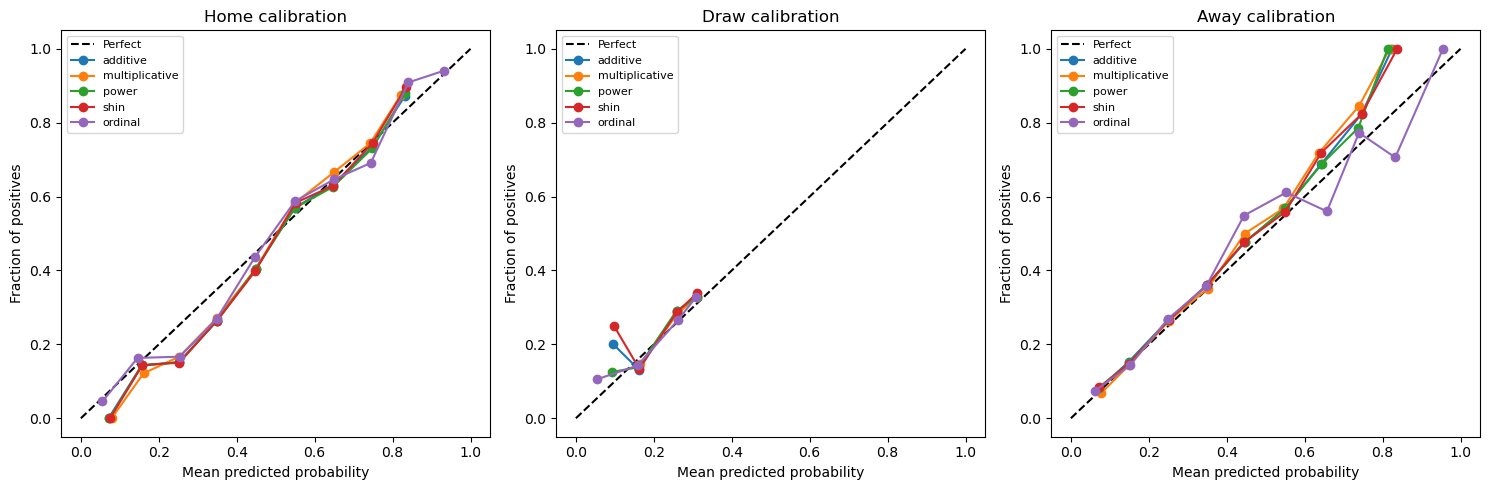

In [73]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

actual = data_test["FTR"].map({"A": 0, "D": 1, "H": 2})

methods = {
    "additive":       ["addAway",  "addDraw",  "addHome"],
    "multiplicative": ["multAway", "multDraw", "multHome"],
    "power":          ["powerA",   "powerD",   "powerH"],
    "shin":           ["shinA",    "shinD",    "shinH"],
    "ordinal":        ["ordinalA", "ordinalD", "ordinalH"],
}

outcomes = {"Home": 2, "Draw": 1, "Away": 0}
outcome_cols = [2, 1, 0]  # index into cols list

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (outcome_name, outcome_val) in zip(axes, outcomes.items()):
    binary_actual = (actual == outcome_val).astype(int)
    ax.plot([0, 1], [0, 1], "k--", label="Perfect")
    
    for name, cols in methods.items():
        col_idx = outcome_val  # A=col0, D=col1, H=col2
        probs = data_test[cols[col_idx]]
        fraction_of_positives, mean_predicted = calibration_curve(binary_actual, probs, n_bins=10)
        ax.plot(mean_predicted, fraction_of_positives, marker="o", label=name)
    
    ax.set_title(f"{outcome_name} calibration")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("1X2Cal.pdf")
plt.show()